## MODELO 2 YOLO

In [ ]:
# BLOQUE 1 — Instalación
!pip install -q ultralytics kagglehub split-folders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 27.7 MB/s eta 0:00:00


In [ ]:
# BLOQUE 2 — Descargar Dataset
import kagglehub

path = kagglehub.dataset_download(
    "mdismielhossenabir/braille-character-image-classification"
)

print("Dataset descargado en:", path)

100%|██████████| 990k/990k [00:00<00:00, 26.9MB/s]

Extracting files...


Dataset descargado en: /root/.cache/kagglehub/datasets/mdismielhossenabir/braille-character-image-classification/versions/1


In [ ]:
#BLOQUE 3 — Detectar Carpeta Base

import os

base_path = path

for item in os.listdir(path):
    item_path = os.path.join(path, item)
    if os.path.isdir(item_path):
        subdirs = os.listdir(item_path)
        if len(subdirs) > 0:
            base_path = item_path
            break

print("Base path detectado:", base_path)

Base path detectado: /root/.cache/kagglehub/datasets/mdismielhossenabir/braille-character-image-classification/versions/1/Braille Alphabet Image Dataset (A–Z)


In [ ]:
#BLOQUE 4 — Crear Split Train/Val/Test
import splitfolders

output_path = "/content/braille_split"

splitfolders.ratio(
    base_path,
    output=output_path,
    seed=42,
    ratio=(0.70, 0.15, 0.15)
)

Copying files: 2600 files [00:00, 3654.56 files/s]


In [ ]:
#BLOQUE 5 — Visualizar Dataset
for folder in ["train", "val", "test"]:
    folder_path = os.path.join(output_path, folder)
    total = sum(
        len(os.listdir(os.path.join(folder_path, cls)))
        for cls in os.listdir(folder_path)
    )
    print(f"{folder}: {total} imágenes")

train: 1820 imágenes
val: 390 imágenes
test: 390 imágenes


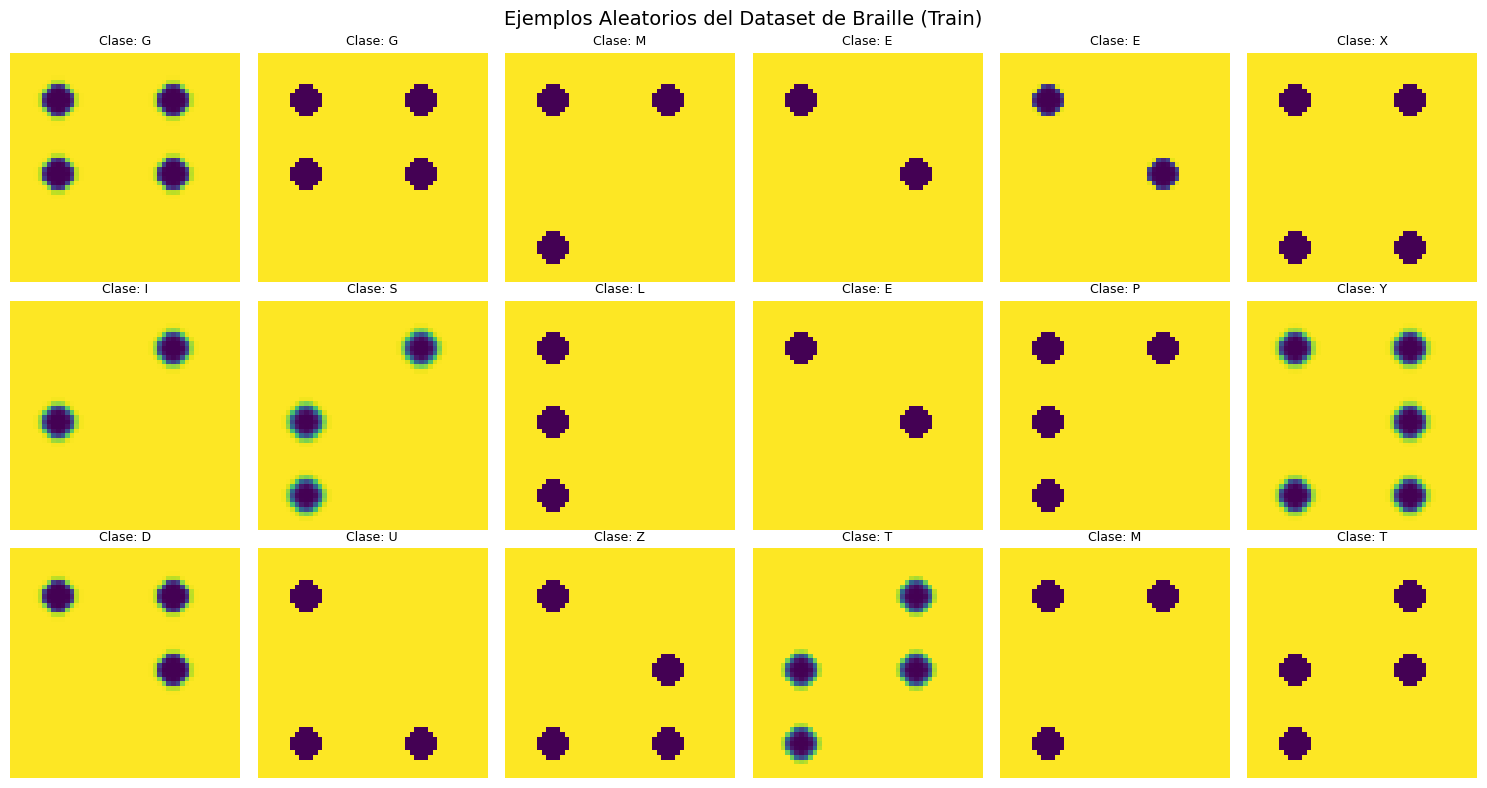

In [ ]:
# BLOQUE 5.1 — Visualización de Ejemplos del Dataset
import matplotlib.pyplot as plt
import random
from PIL import Image

train_path = os.path.join(output_path, "train")

# Obtener clases disponibles
classes = sorted(os.listdir(train_path))

fig, axes = plt.subplots(3, 6, figsize=(15, 8))
axes = axes.flatten()

for ax in axes:
    # Seleccionar clase aleatoria
    cls = random.choice(classes)
    cls_path = os.path.join(train_path, cls)

    # Seleccionar imagen aleatoria dentro de la clase
    img_name = random.choice(os.listdir(cls_path))
    img_path = os.path.join(cls_path, img_name)

    # Cargar imagen
    img = Image.open(img_path)

    # Mostrar
    ax.imshow(img)
    ax.set_title(f"Clase: {cls}", fontsize=9)
    ax.axis("off")

plt.suptitle("Ejemplos Aleatorios del Dataset de Braille (Train)", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
#BLOQUE 6 — Entrenar YOLO
from ultralytics import YOLO

model = YOLO("yolov8n-cls.pt")

results = model.train(
    data=output_path,
    epochs=30,
    imgsz=64,
    batch=32,
    project="braille_project",
    name="yolo_braille"
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/braille_split, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=64

In [ ]:
#BLOQUE 7 — Validación
metrics = model.val()
print(metrics)

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
YOLOv8n-cls summary (fused): 30 layers, 1,468,186 parameters, 0 gradients, 3.3 GFLOPs
train: /content/braille_split/train... found 1820 images in 26 classes ✅ 
val: /content/braille_split/val... found 390 images in 26 classes ✅ 
test: /content/braille_split/test... found 390 images in 26 classes ✅ 
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 5.4±1.8 MB/s, size: 0.1 KB)
val: Scanning /content/braille_split/val... 390 images, 0 corrupt: 100% ━━━━━━━━━━━━ 390/390 109.1Mit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 25/25 27.6it/s 0.9s
                   all          1          1
Speed: 0.0ms preprocess, 1.5ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /content/runs/classify/val
ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7a9c7415c530>
curves: []
curves_re

In [ ]:
#BLOQUE 8 — Predicciones de Ejemplo
results = model.predict(
    source="/content/braille_split/test/A",
    save=True
)


image 1/15 /content/braille_split/test/A/A_11.png: 64x64 A 0.96, U 0.02, K 0.02, C 0.00, E 0.00, 4.9ms
image 2/15 /content/braille_split/test/A/A_12.png: 64x64 A 0.96, U 0.02, K 0.01, C 0.00, E 0.00, 6.3ms
image 3/15 /content/braille_split/test/A/A_19.png: 64x64 A 0.96, U 0.02, K 0.02, C 0.00, E 0.00, 10.0ms
image 4/15 /content/braille_split/test/A/A_20.png: 64x64 A 0.95, U 0.02, K 0.02, C 0.00, E 0.00, 4.2ms
image 5/15 /content/braille_split/test/A/A_21.png: 64x64 A 0.96, U 0.02, K 0.02, C 0.00, E 0.00, 3.8ms
image 6/15 /content/braille_split/test/A/A_24.png: 64x64 A 0.94, U 0.03, K 0.02, C 0.00, E 0.00, 4.4ms
image 7/15 /content/braille_split/test/A/A_34.png: 64x64 A 0.95, U 0.03, K 0.02, C 0.00, E 0.00, 4.6ms
image 8/15 /content/braille_split/test/A/A_37.png: 64x64 A 0.96, U 0.02, K 0.01, C 0.00, E 0.00, 4.4ms
image 9/15 /content/braille_split/test/A/A_40.png: 64x64 A 0.95, U 0.03, K 0.02, C 0.00, E 0.00, 4.3ms
image 10/15 /content/braille_split/test/A/A_58.png: 64x64 A 0.90, U 0.0

In [ ]:
import os

for root, dirs, files in os.walk("/content"):
    if "results.csv" in files:
        print("Encontrado en:", os.path.join(root, "results.csv"))

Encontrado en: /content/runs/classify/braille_project/yolo_braille/results.csv


In [ ]:
print(df.columns.tolist())

['epoch', 'time', 'train/loss', 'metrics/accuracy_top1', 'metrics/accuracy_top5', 'val/loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


Archivo encontrado: /content/runs/classify/braille_project/yolo_braille/results.csv


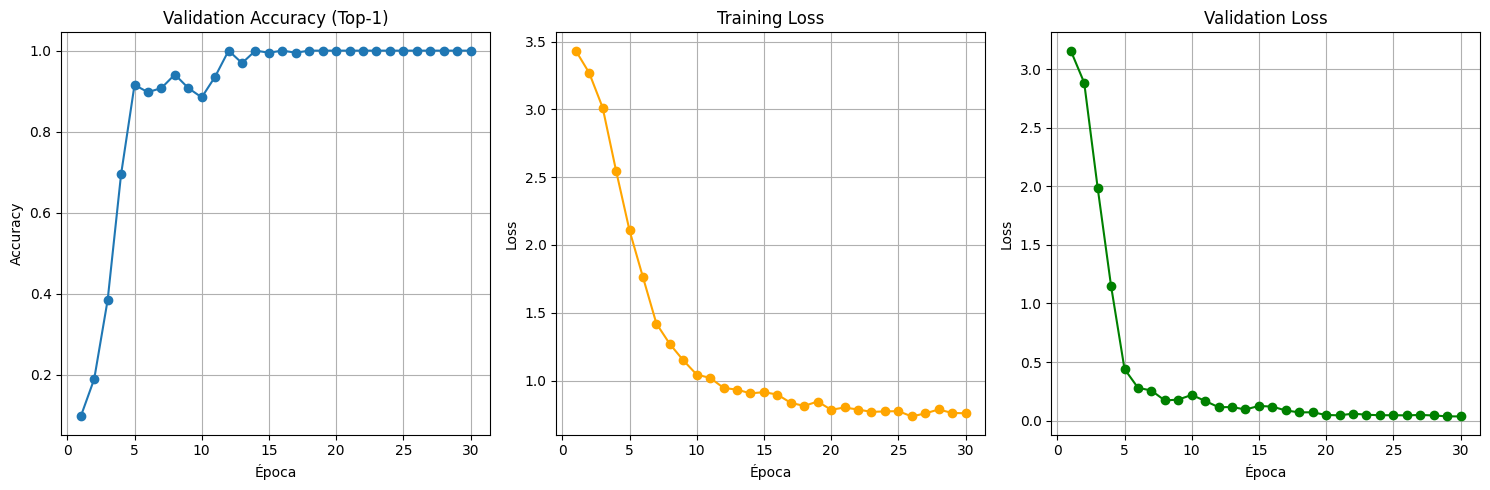

In [ ]:
# ============================================================
# BLOQUE 9: Curvas de entrenamiento YOLO Classification
# ============================================================
import os
import pandas as pd
import matplotlib.pyplot as plt

# Buscar results.csv automáticamente
results_csv = None

for root, dirs, files in os.walk("/content"):
    if "results.csv" in files:
        results_csv = os.path.join(root, "results.csv")
        break

print("Archivo encontrado:", results_csv)

df = pd.read_csv(results_csv)

plt.figure(figsize=(15,5))

# Accuracy de validación
plt.subplot(1,3,1)
plt.plot(df['epoch'], df['metrics/accuracy_top1'], marker='o')
plt.title('Validation Accuracy (Top-1)')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.grid()

# Loss de entrenamiento
plt.subplot(1,3,2)
plt.plot(df['epoch'], df['train/loss'], marker='o', color='orange')
plt.title('Training Loss')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.grid()

# Loss de validación
plt.subplot(1,3,3)
plt.plot(df['epoch'], df['val/loss'], marker='o', color='green')
plt.title('Validation Loss')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.grid()

plt.tight_layout()
plt.show()

In [ ]:
# BLOQUE 9.1: Resumen de métricas

final_epoch = df.iloc[-1]

val_top1 = final_epoch['metrics/accuracy_top1'] * 100
val_top5 = final_epoch['metrics/accuracy_top5'] * 100

print("===== MÉTRICAS FINALES DEL MODELO YOLO =====\n")

print(f"Época final:                {int(final_epoch['epoch'])}")
print(f"Training Loss Final:        {final_epoch['train/loss']:.4f}")
print(f"Validation Loss Final:      {final_epoch['val/loss']:.4f}")
print(f"Validation Accuracy Top-1:  {val_top1:.2f}%")
print(f"Validation Accuracy Top-5:  {val_top5:.2f}%")

===== MÉTRICAS FINALES DEL MODELO YOLO =====

Época final:                30
Training Loss Final:        0.7581
Validation Loss Final:      0.0352
Validation Accuracy Top-1:  100.00%
Validation Accuracy Top-5:  100.00%


In [ ]:
#BLOQUE TEST
test_metrics = model.val(
    data=output_path,
    split='test'
)

print(test_metrics)

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
train: /content/braille_split/train... found 1820 images in 26 classes ✅ 
val: /content/braille_split/val... found 390 images in 26 classes ✅ 
test: /content/braille_split/test... found 390 images in 26 classes ✅ 
test: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4.9±1.5 MB/s, size: 0.1 KB)
test: Scanning /content/braille_split/test... 390 images, 0 corrupt: 100% ━━━━━━━━━━━━ 390/390 6.8Kit/s 0.1s
test: New cache created: /content/braille_split/test.cache
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 25/25 29.1it/s 0.9s
                   all          1          1
Speed: 0.0ms preprocess, 1.4ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /content/runs/classify/val2
ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7a9c688d6b70>
curves: []
curves_results: []
fitness: 1.0
ke

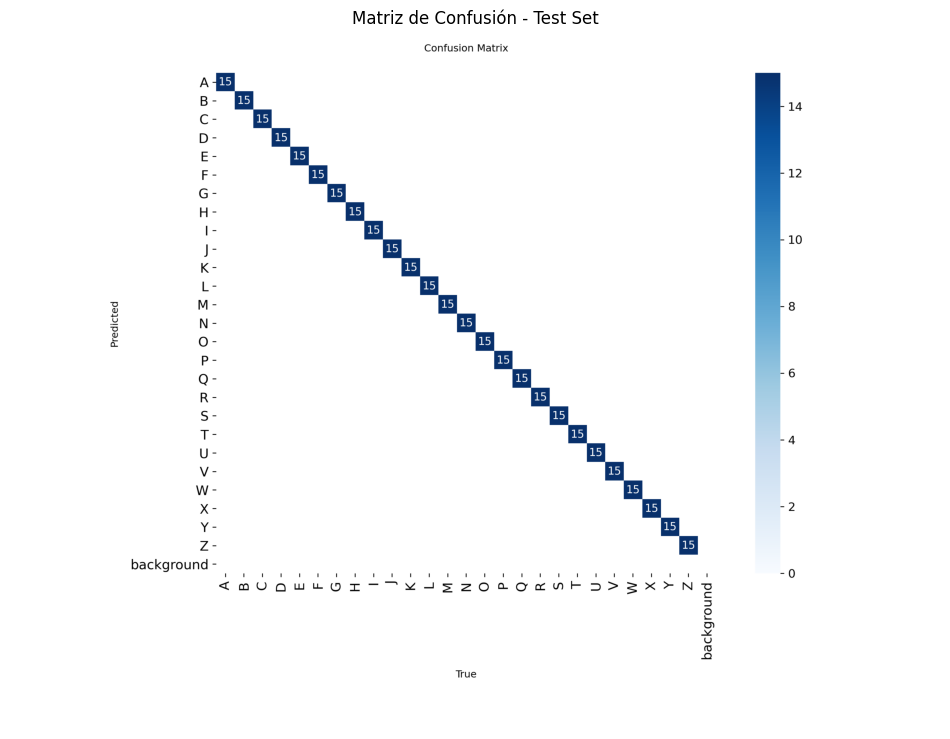

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import os

conf_matrix_path = "/content/runs/classify/val2/confusion_matrix.png"

img = Image.open(conf_matrix_path)

plt.figure(figsize=(12,10))
plt.imshow(img)
plt.axis('off')
plt.title("Matriz de Confusión - Test Set")
plt.show()

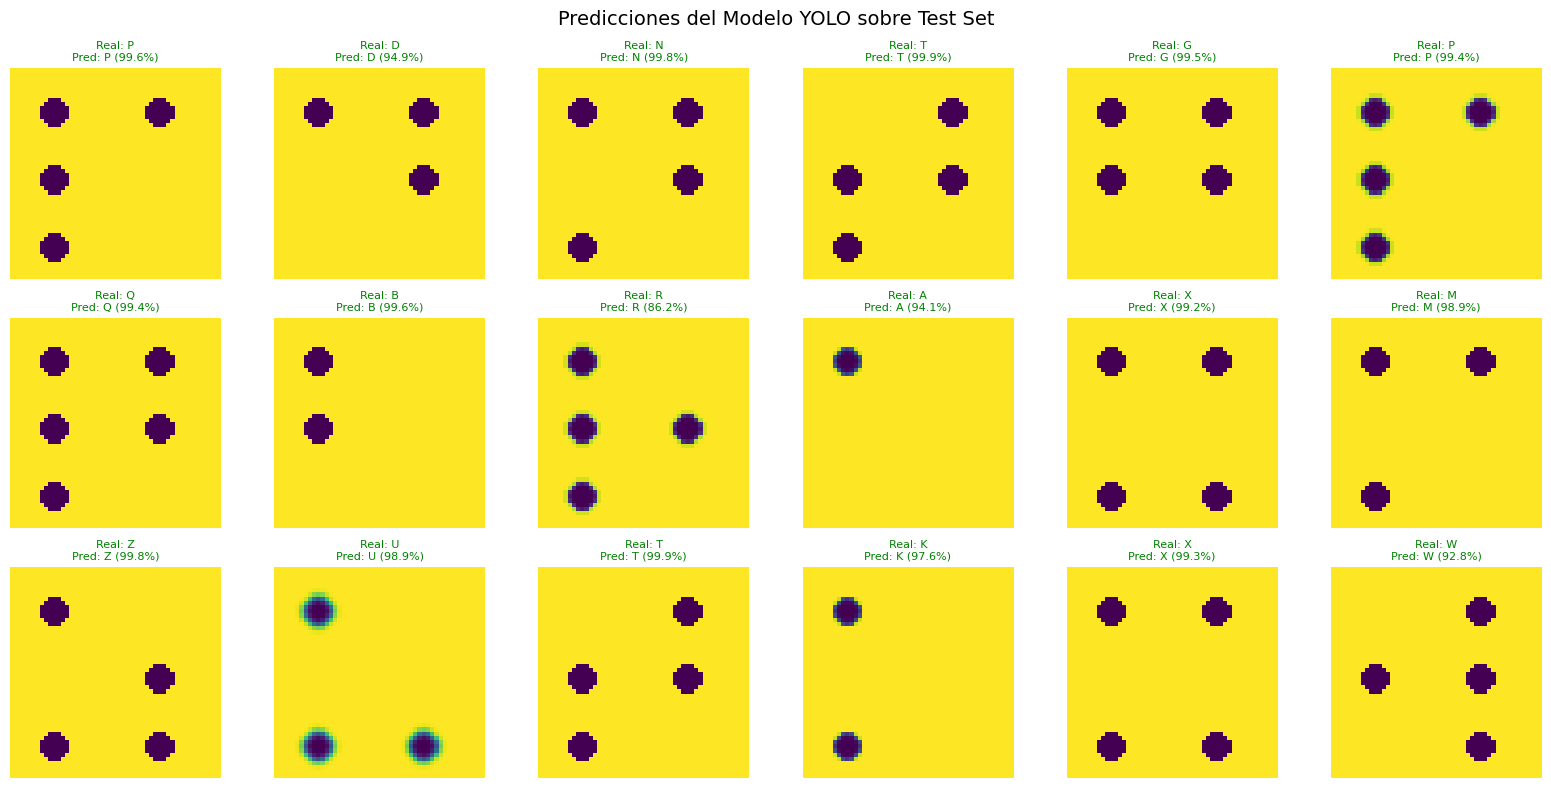

In [ ]:
# BLOQUE 11: Predicciones visuales individuales con YOLO
import random
from PIL import Image
import matplotlib.pyplot as plt
import os

test_path = os.path.join(output_path, "test")
class_names = sorted(os.listdir(test_path))

samples = []

# Tomar imágenes aleatorias del test set
for _ in range(18):
    cls = random.choice(class_names)
    cls_path = os.path.join(test_path, cls)

    img_name = random.choice(os.listdir(cls_path))
    img_path = os.path.join(cls_path, img_name)

    samples.append((img_path, cls))

fig, axes = plt.subplots(3, 6, figsize=(16,8))
axes = axes.flatten()

for i, (img_path, true_label) in enumerate(samples):

    results = model.predict(img_path, verbose=False)

    pred_idx = results[0].probs.top1
    confidence = results[0].probs.top1conf.item() * 100
    pred_label = class_names[pred_idx]

    img = Image.open(img_path)

    color = 'green' if pred_label == true_label else 'red'

    axes[i].imshow(img)
    axes[i].set_title(
        f"Real: {true_label}\nPred: {pred_label} ({confidence:.1f}%)",
        color=color,
        fontsize=8
    )
    axes[i].axis('off')

plt.suptitle("Predicciones del Modelo YOLO sobre Test Set", fontsize=14)
plt.tight_layout()
plt.show()